# Node-catalog tour: SWIR pill-tray inspection, driven by a CuvisPipeline

This notebook walks a broad slice of the **cuvis-ai** node catalog over a single
short-wave infrared (SWIR) hyperspectral acquisition of a tray of visually
near-identical white tablets, one product per compartment. Everything runs
**through the framework**: nodes are wired into a `CuvisPipeline`, the stateful
nodes are fitted with `StatisticalTrainer`, and inference runs with `Predictor`.
The figures are themselves node outputs: `SpectraPlot` draws the spectra and the
overlay / colourise / concatenate nodes build the label maps, `PngWriter` writes
each strip to disk, and the notebook only displays the resulting PNGs (the same
framework-first pattern as `blood_perfusion.ipynb`). We never call
`node.forward(...)` by hand.

**The data.** SWIR session at
`data/Pills/swir_pills_tray_01.cu3s` (200x200 px, 39 bands, 980-1664 nm,
calibrated Reflectance). Two rotated re-scans (`swir_pills_tray_02/03`) ship
alongside. 

**The question.** In the visible range these tablets look identical (white,
round). In the SWIR the molecular overtone absorptions differ, so the question is
whether the **spectra** can separate the 16 compartments. The inspection graph is
a branched DAG:

```
CU3SDataNode ─┬─> BlobDetector ───────────────────► 16 compartments (spatial)
              │        └────────(blob mask)────────────────────────┐
              └─> ContinuumRemoval ─┬─> SpectralSignatureExtractor  │
                                    │      └─> SignaturesToReferences│
                                    │            └─> SpectralAngleMapper ─> MajorityVoteByBlob ─► clean map
                                    └─> KMeansClusterer / GaussianMixtureClusterer ─► spectral clusters
```

**Nodes shown:** `CU3SDataNode`, `BlobDetector`, `ContinuumRemoval`,
`SNVCorrection`, `SpectralDerivative`, `SavitzkyGolay`,
`SpectralSignatureExtractor`, `SignaturesToReferences`, `SpectralAngleMapper`,
`MajorityVoteByBlob`, `KMeansClusterer`, `GaussianMixtureClusterer`,
`FixedWavelengthSelector`, `TrackingOverlayNode`, `ClassMapToRGB`, `LabelOverlay`,
`TitleOverlay`, `LegendStrip`, `SpectraPlot`, `ImageConcatenator`, `PngWriter`,
and the `DistinctLabelCount` metric node.

## Setup

This notebook runs a real `.cu3s` acquisition through the framework on CPU, so it
needs the cu3s data layer and the Cuvis SDK on top of the base install:

```bash
# base environment, including Jupyter
uv sync --extra dev

# cu3s reader + Cuvis SDK (pulls cuvis and, on Windows, cuvis-il)
uv pip install "cuvis-ai-dataloader[cu3s]"

# launch
uv run jupyter notebook
```

The example expects the SWIR Pills scans under `data/Pills/`
(`swir_pills_tray_01.cu3s` is the working frame; `02` / `03` are rotated re-scans).

In [1]:
import base64
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from cuvis_ai_dataloader.data import Cu3sDataModule
from IPython.display import HTML, display
from loguru import logger as _loguru_logger

from cuvis_ai.node.anomaly_visualization import TrackingOverlayNode
from cuvis_ai.node.blob_detector import BlobDetector
from cuvis_ai.node.channel_selector import FixedWavelengthSelector
from cuvis_ai.node.clustering.gmm import GaussianMixtureClusterer
from cuvis_ai.node.clustering.kmeans import KMeansClusterer
from cuvis_ai.node.colormap import ClassMapToRGB
from cuvis_ai.node.compositing import (
    ImageConcatenator,
    LabelOverlay,
    LegendStrip,
    TitleOverlay,
)
from cuvis_ai.node.data import CU3SDataNode
from cuvis_ai.node.image_file import PngWriter
from cuvis_ai.node.mask_ops import LabelOffset, MajorityVoteByBlob
from cuvis_ai.node.metrics import DistinctLabelCount
from cuvis_ai.node.pretreatments.continuum_removal import ContinuumRemoval
from cuvis_ai.node.pretreatments.savitzky_golay import SavitzkyGolay
from cuvis_ai.node.pretreatments.snv import SNVCorrection
from cuvis_ai.node.pretreatments.spectral_derivative import SpectralDerivative
from cuvis_ai.node.spectral_angle_mapper import SpectralAngleMapper
from cuvis_ai.node.spectral_extractor import SignaturesToReferences, SpectralSignatureExtractor
from cuvis_ai.node.spectrum_plot import SpectraPlot
from cuvis_ai_core.pipeline.pipeline import CuvisPipeline
from cuvis_ai_core.training import Predictor, StatisticalTrainer

# Quiet noisy third-party logging (cuvis SDK + dataloader) for a clean notebook.
logging.getLogger().setLevel(logging.CRITICAL)
_loguru_logger.remove()

torch.manual_seed(0)
# The SWIR cube is small (200x200x39) and every op here is light, so we run on
# CPU to keep the example reproducible and dependency-light. CUDA also works.
device = torch.device("cpu")
print("device:", device)

W0630 12:26:45.084000 60428 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


device: cpu


## 0. Data

`swir_pills_tray_01.cu3s` is the working scan (one product per compartment).
`dm()` builds a one-frame `Cu3sDataModule` in calibrated Reflectance mode; every
pipeline below is fitted and/or run against it.

In [2]:
DATA_DIR = Path("../../data/Pills")
CU3S = DATA_DIR / "swir_pills_tray_01.cu3s"
assert CU3S.exists(), f"missing {CU3S}"

# graphviz renders of each pipeline DAG land here (gitignored)
RENDER_DIR = Path("output")
RENDER_DIR.mkdir(parents=True, exist_ok=True)

# one shared 16-colour palette (tab20, as RGB 0-255) so the spectra lines, the
# cluster maps, and their legends all agree on a colour per id.
PALETTE = [tuple(int(round(255 * c)) for c in plt.get_cmap("tab20")(i)[:3]) for i in range(16)]


def show_image(png_path: Path | str) -> HTML:
    """Display a PNG that expands to full size on click (CSS only, no plugin).

    The PNG is embedded as a base64 data URI inside a ``<label>`` that wraps a hidden checkbox;
    clicking toggles ``:checked``, which drops the image's ``max-width`` cap from the cell width to
    native size and lets the box scroll. Pure HTML/CSS, so it also survives ``nbconvert`` export.
    """
    b64 = base64.b64encode(Path(png_path).read_bytes()).decode()
    return HTML(
        "<style>.cuvis-zoom input{display:none}"
        ".cuvis-zoom{display:block;overflow:auto;max-height:70vh}"
        ".cuvis-zoom img{max-width:100%;height:auto;cursor:zoom-in}"
        ".cuvis-zoom input:checked~img{max-width:none;cursor:zoom-out}</style>"
        '<label class="cuvis-zoom" title="click to expand / collapse">'
        f'<input type="checkbox"><img src="data:image/png;base64,{b64}"></label>'
    )


def dm() -> Cu3sDataModule:
    """One-frame Reflectance Cu3sDataModule for the working pill tray."""
    return Cu3sDataModule(
        cu3s_file_path=str(CU3S),
        processing_mode="Reflectance",
        batch_size=1,
        measurement_indices=[0],
    )

## 1. Localize the compartments, then ask if their spectra differ

The **inspection pipeline** is a single branched DAG:

- `BlobDetector` reduces the cube to a brightness image, thresholds it (Otsu),
  cleans it, and labels connected components, pinning the count to the 16 tray
  compartments with `keep_largest=16`.
- `ContinuumRemoval` divides each spectrum by its upper convex hull, isolating
  the absorption-feature shape from the excipient-dominated baseline.
- `SpectralSignatureExtractor` averages the continuum-removed spectra inside each
  blob; `SignaturesToReferences` turns those into one reference per compartment;
  `SpectralAngleMapper` scores every pixel against all 16 references; and
  `MajorityVoteByBlob` collapses the noisy per-pixel labels to one label per
  compartment.

`BlobDetector` reads brightness from the raw cube (continuum removal flattens the
brightness it needs), so the cube fans out to both branches. `wavelengths` is
wired explicitly from the data node (it carries the numpy dtype the nodes expect).
All nodes here are stateless, so a single `Predictor` run drives the whole graph.

In [3]:
data = CU3SDataNode(name="data")
blobs = BlobDetector(
    brightness="band_mean",
    threshold_method="otsu",
    min_area=150,
    opening_kernel=3,
    closing_kernel=3,
    keep_largest=16,
    name="blobs",
)
continuum = ContinuumRemoval(name="continuum")
signatures = SpectralSignatureExtractor(name="signatures")
references = SignaturesToReferences(name="references")
sam = SpectralAngleMapper(num_channels=39, name="sam")
vote = MajorityVoteByBlob(name="vote")
# count the distinct compartment labels that survive the vote, in-graph
labelcount = DistinctLabelCount(name="labelcount")
# false-RGB from three SWIR bands as a node, not a hand-rolled band pick;
# per-frame norm suits a single frame
false_rgb = FixedWavelengthSelector(
    target_wavelengths=(1450.0, 1250.0, 1050.0), norm_mode="per_frame", name="false_rgb"
)

inspection_pipeline = CuvisPipeline("pill_inspection")
inspection_pipeline.connect(
    (data.outputs.cube, blobs.inputs.cube),
    (data.outputs.wavelengths, blobs.inputs.wavelengths),
    (data.outputs.cube, continuum.inputs.cube),
    (data.outputs.wavelengths, continuum.inputs.wavelengths),
    (continuum.outputs.cube, signatures.inputs.cube),
    (data.outputs.wavelengths, signatures.inputs.wavelengths),
    (blobs.outputs.mask, signatures.inputs.mask),
    (signatures.outputs.signatures, references.inputs.signatures),
    (continuum.outputs.cube, sam.inputs.cube),
    (references.outputs.spectral_signature, sam.inputs.spectral_signature),
    (sam.outputs.identity_mask, vote.inputs.identity_mask),
    (blobs.outputs.mask, vote.inputs.blob_mask),
    (vote.outputs.mask, labelcount.inputs.mask),
    (data.outputs.cube, false_rgb.inputs.cube),
    (data.outputs.wavelengths, false_rgb.inputs.wavelengths),
)
inspection_pipeline.to(device)

pill_inspection:
CU3SDataNode()
BlobDetector()
ContinuumRemoval()
SpectralSignatureExtractor()
SignaturesToReferences()
SpectralAngleMapper()
MajorityVoteByBlob()
DistinctLabelCount()
FixedWavelengthSelector()
Use `pipeline.visualize()` for Graphviz/Mermaid output.


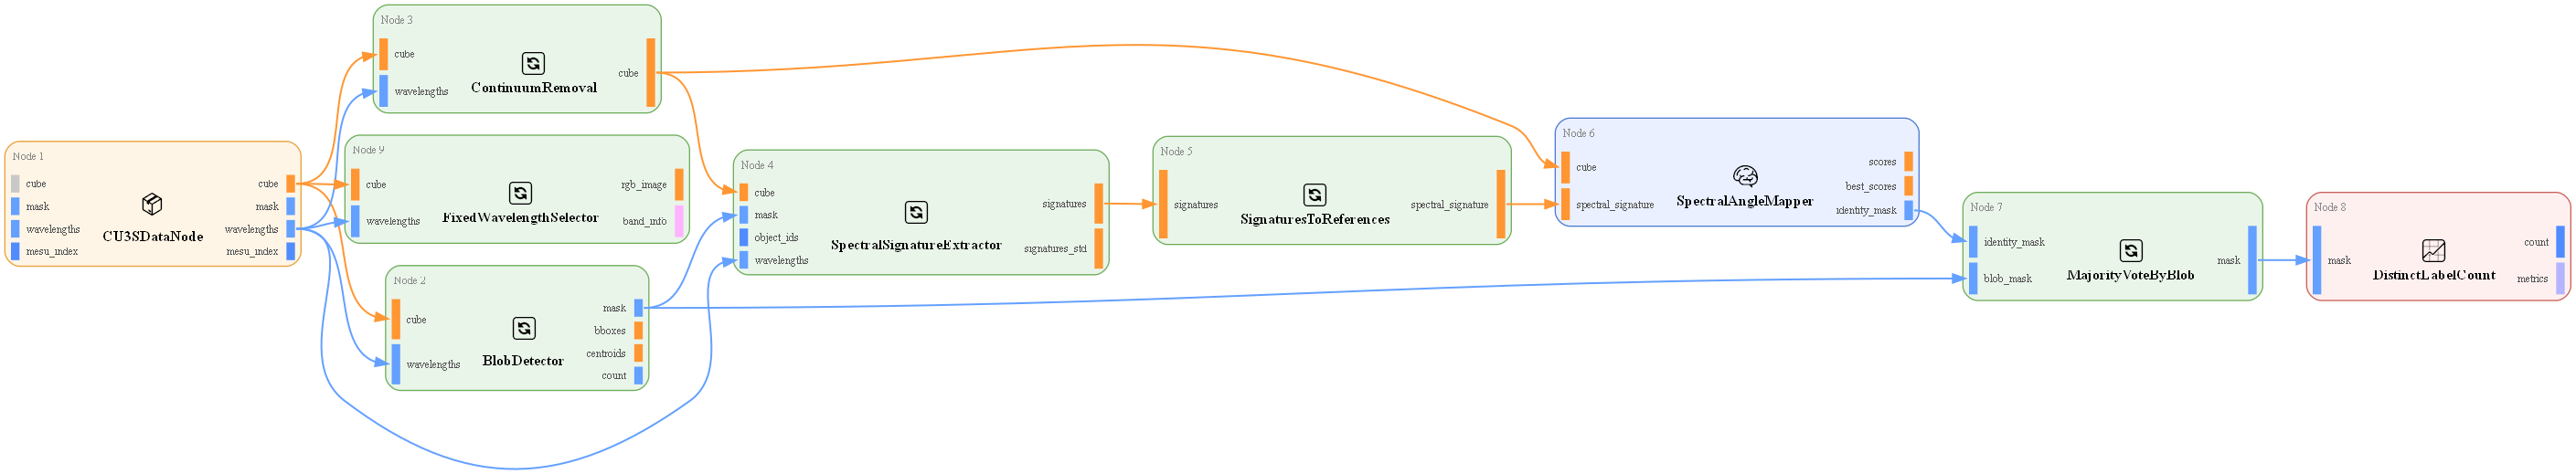

In [4]:
graph_png = inspection_pipeline.visualize(
    format="render_graphviz",
    output_path=str(RENDER_DIR / f"{inspection_pipeline.name}.png"),
)
display(show_image(graph_png))  # click the image to expand it to full size inline

In [5]:
# Run the inspection pipeline once. The compartment count and distinct-label count
# after the vote are node outputs (blobs.count and the DistinctLabelCount node).
out = Predictor(pipeline=inspection_pipeline, datamodule=dm()).predict(collect_outputs=True)[0]
print("collected:", [f"{n}.{p}" for (n, p) in out.keys()])

n_blobs = int(out[("blobs", "count")].item())
n_labels = int(out[("labelcount", "count")][0].item())
print(f"compartments detected: {n_blobs} | distinct labels after vote: {n_labels}")

Predict [pill_inspection]:   0%|          | 0/1 [00:00<?, ?batch/s]

collected: ['data.cube', 'data.wavelengths', 'data.mesu_index', 'blobs.mask', 'blobs.bboxes', 'blobs.centroids', 'blobs.count', 'continuum.cube', 'false_rgb.rgb_image', 'false_rgb.band_info', 'signatures.signatures', 'signatures.signatures_std', 'references.spectral_signature', 'sam.scores', 'sam.best_scores', 'sam.identity_mask', 'vote.mask', 'labelcount.count', 'labelcount.metrics']
compartments detected: 16 | distinct labels after vote: 16


## 2. Inspection results, assembled in-graph

The label-map panels are built **inside a render pipeline**, not by hand in
matplotlib. `FixedWavelengthSelector` makes the SWIR false-RGB; two
`TrackingOverlayNode`s paint the detected blob map and the per-compartment
majority vote onto it, printing each compartment id directly on the blobs;
`TitleOverlay` captions each panel; and `ImageConcatenator` stitches them into
one strip. matplotlib only displays the finished node output. The per-pixel
Spectral Angle Mapper labels are soft (the excipient dominates any single pixel),
so `MajorityVoteByBlob` reduces them to a clean one-label-per-compartment map.
Every compartment recovering a distinct label means the 16 products are mutually
separable within this scan, each compartment being its own reference.

Predict [pill_inspection_panels]:   0%|          | 0/1 [00:00<?, ?batch/s]


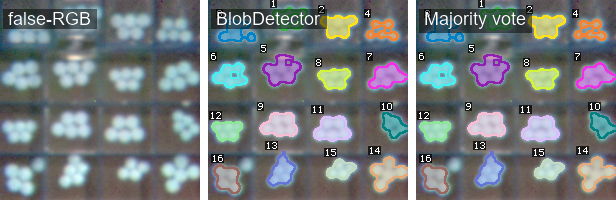

In [6]:
# The three label-map panels are assembled by a render pipeline: TrackingOverlayNode
# colours each id-map and prints the compartment id, TitleOverlay captions it,
# ImageConcatenator stitches the strip, and PngWriter writes it to output/.
p2_data = CU3SDataNode(name="data")
p2_blobs = BlobDetector(
    brightness="band_mean",
    threshold_method="otsu",
    min_area=150,
    opening_kernel=3,
    closing_kernel=3,
    keep_largest=16,
    name="blobs",
)
p2_continuum = ContinuumRemoval(name="continuum")
p2_sig = SpectralSignatureExtractor(name="signatures")
p2_ref = SignaturesToReferences(name="references")
p2_sam = SpectralAngleMapper(num_channels=39, name="sam")
p2_vote = MajorityVoteByBlob(name="vote")
p2_rgb = FixedWavelengthSelector(
    target_wavelengths=(1450.0, 1250.0, 1050.0), norm_mode="per_frame", name="false_rgb"
)
# short per-panel captions sized to the 200 px panels; TrackingOverlayNode draws the
# compartment ids at text_scale=1 so the numbers stay small.
t_rgb = TitleOverlay(text="false-RGB", font_size=18, name="t_rgb")
blob_panel = TrackingOverlayNode(draw_ids=True, text_scale=1, name="blob_panel")
t_blob = TitleOverlay(text="BlobDetector", font_size=18, name="t_blob")
voted_panel = TrackingOverlayNode(draw_ids=True, text_scale=1, name="voted_panel")
t_voted = TitleOverlay(text="Majority vote", font_size=18, name="t_voted")
panels_strip = ImageConcatenator(gap=8, bg_color=(1.0, 1.0, 1.0), name="strip")
panels_png = PngWriter(output_path=str(RENDER_DIR / "pill_inspection_panels_strip.png"), name="png")

panels_pipeline = CuvisPipeline("pill_inspection_panels")
panels_pipeline.connect(
    # the inspection graph from section 1 ...
    (p2_data.outputs.cube, p2_blobs.inputs.cube),
    (p2_data.outputs.wavelengths, p2_blobs.inputs.wavelengths),
    (p2_data.outputs.cube, p2_continuum.inputs.cube),
    (p2_data.outputs.wavelengths, p2_continuum.inputs.wavelengths),
    (p2_continuum.outputs.cube, p2_sig.inputs.cube),
    (p2_data.outputs.wavelengths, p2_sig.inputs.wavelengths),
    (p2_blobs.outputs.mask, p2_sig.inputs.mask),
    (p2_sig.outputs.signatures, p2_ref.inputs.signatures),
    (p2_continuum.outputs.cube, p2_sam.inputs.cube),
    (p2_ref.outputs.spectral_signature, p2_sam.inputs.spectral_signature),
    (p2_sam.outputs.identity_mask, p2_vote.inputs.identity_mask),
    (p2_blobs.outputs.mask, p2_vote.inputs.blob_mask),
    # ... plus a render tail that paints, captions, stitches, and writes the three panels.
    (p2_data.outputs.cube, p2_rgb.inputs.cube),
    (p2_data.outputs.wavelengths, p2_rgb.inputs.wavelengths),
    (p2_rgb.outputs.rgb_image, t_rgb.inputs.frame),
    (p2_rgb.outputs.rgb_image, blob_panel.inputs.rgb_image),
    (p2_blobs.outputs.mask, blob_panel.inputs.mask),
    (blob_panel.outputs.rgb_with_overlay, t_blob.inputs.frame),
    (p2_rgb.outputs.rgb_image, voted_panel.inputs.rgb_image),
    (p2_vote.outputs.mask, voted_panel.inputs.mask),
    (voted_panel.outputs.rgb_with_overlay, t_voted.inputs.frame),
    # ImageConcatenator fans in: panels appear left-to-right in connection order.
    (t_rgb.outputs.frame, panels_strip.inputs.images),
    (t_blob.outputs.frame, panels_strip.inputs.images),
    (t_voted.outputs.frame, panels_strip.inputs.images),
    (panels_strip.outputs.rgb_image, panels_png.inputs.rgb_image),
)
panels_pipeline.to(device)

# PngWriter drops the strip to output/; show_image displays the file (click to expand).
Predictor(pipeline=panels_pipeline, datamodule=dm()).predict(collect_outputs=False)
display(show_image(RENDER_DIR / "pill_inspection_panels_strip.png"))

## 3. Why continuum removal? A pretreatment comparison, rendered with nodes

The compartments overlap in calibrated reflectance because a tablet is mostly
common excipient (lactose, cellulose), so the bulk reflectance is dominated by
the filler and the discriminating active-ingredient absorptions are a small
overlay. This pipeline runs four pretreatment nodes off the same cube
(`SNVCorrection`, `ContinuumRemoval`, `SpectralDerivative`, `SavitzkyGolay`),
averages each transform inside the 16 blobs with a `SpectralSignatureExtractor`,
and then renders the comparison **in-graph**: one `SpectraPlot` per pretreatment
draws the 16 per-compartment mean spectra overlaid on one axes (colour =
compartment, shared `PALETTE`), `ImageConcatenator` tiles the four panels into a
2x2 grid, and `LegendStrip` appends the compartment-colour key. matplotlib only
displays the finished node output.

In [7]:
pre_data = CU3SDataNode(name="data")
pre_blobs = BlobDetector(threshold_method="otsu", min_area=150, keep_largest=16, name="blobs")
snv = SNVCorrection(name="snv")
cr = ContinuumRemoval(name="continuum")
deriv2 = SpectralDerivative(order=2, name="deriv2")
savgol = SavitzkyGolay(name="savgol")
# one per-compartment mean-spectrum extractor per pretreatment, so each SpectraPlot
# renders a node's `signatures` output instead of averaging pixels by hand
sig_savgol = SpectralSignatureExtractor(name="sig_savgol")
sig_snv = SpectralSignatureExtractor(name="sig_snv")
sig_continuum = SpectralSignatureExtractor(name="sig_continuum")
sig_deriv2 = SpectralSignatureExtractor(name="sig_deriv2")
# one SpectraPlot per pretreatment: 16 per-compartment mean spectra overlaid on one
# axes, coloured by the shared PALETTE so they match the LegendStrip key below.
plot_savgol = SpectraPlot(
    palette=PALETTE,
    title="Reflectance (Savitzky-Golay)",
    ylabel="reflectance (×10⁴)",
    name="plot_savgol",
)
plot_snv = SpectraPlot(palette=PALETTE, title="SNV", ylabel="SNV (z)", name="plot_snv")
plot_continuum = SpectraPlot(
    palette=PALETTE,
    title="Continuum removed",
    ylabel="continuum-removed (ratio)",
    name="plot_continuum",
)
plot_deriv2 = SpectraPlot(
    palette=PALETTE, title="2nd derivative", ylabel="2nd derivative", name="plot_deriv2"
)
# tile the four panels into a 2x2 grid (two horizontal rows stacked vertically),
# then append one shared compartment-colour legend.
pre_row1 = ImageConcatenator(axis="horizontal", gap=8, name="row1")
pre_row2 = ImageConcatenator(axis="horizontal", gap=8, name="row2")
pre_grid = ImageConcatenator(axis="vertical", gap=8, name="grid")
comp_entries = [(str(i + 1), PALETTE[i]) for i in range(16)]
pre_legend = LegendStrip(entries=comp_entries, n_columns=8, name="legend")
pre_png = PngWriter(output_path=str(RENDER_DIR / "pill_pretreatments_strip.png"), name="png")

pretreatment_pipeline = CuvisPipeline("pill_pretreatments")
pretreatment_pipeline.connect(
    (pre_data.outputs.cube, pre_blobs.inputs.cube),
    (pre_data.outputs.wavelengths, pre_blobs.inputs.wavelengths),
    (pre_data.outputs.cube, snv.inputs.cube),
    (pre_data.outputs.cube, cr.inputs.cube),
    (pre_data.outputs.wavelengths, cr.inputs.wavelengths),
    (pre_data.outputs.cube, deriv2.inputs.cube),
    (pre_data.outputs.wavelengths, deriv2.inputs.wavelengths),
    (pre_data.outputs.cube, savgol.inputs.cube),
    (pre_data.outputs.wavelengths, savgol.inputs.wavelengths),
    # per-compartment mean spectra, one extractor per pretreatment branch.
    # wavelengths is wired from the data node so its numpy dtype overrides the
    # torch batch auto-inject (the extractor declares an np.int32 wavelengths port).
    (savgol.outputs.cube, sig_savgol.inputs.cube),
    (pre_blobs.outputs.mask, sig_savgol.inputs.mask),
    (pre_data.outputs.wavelengths, sig_savgol.inputs.wavelengths),
    (snv.outputs.cube, sig_snv.inputs.cube),
    (pre_blobs.outputs.mask, sig_snv.inputs.mask),
    (pre_data.outputs.wavelengths, sig_snv.inputs.wavelengths),
    (cr.outputs.cube, sig_continuum.inputs.cube),
    (pre_blobs.outputs.mask, sig_continuum.inputs.mask),
    (pre_data.outputs.wavelengths, sig_continuum.inputs.wavelengths),
    (deriv2.outputs.cube, sig_deriv2.inputs.cube),
    (pre_blobs.outputs.mask, sig_deriv2.inputs.mask),
    (pre_data.outputs.wavelengths, sig_deriv2.inputs.wavelengths),
    # render tail: one multi-series plot per pretreatment, tiled 2x2, with a legend.
    (sig_savgol.outputs.signatures, plot_savgol.inputs.signatures),
    (pre_data.outputs.wavelengths, plot_savgol.inputs.wavelengths),
    (sig_snv.outputs.signatures, plot_snv.inputs.signatures),
    (pre_data.outputs.wavelengths, plot_snv.inputs.wavelengths),
    (sig_continuum.outputs.signatures, plot_continuum.inputs.signatures),
    (pre_data.outputs.wavelengths, plot_continuum.inputs.wavelengths),
    (sig_deriv2.outputs.signatures, plot_deriv2.inputs.signatures),
    (pre_data.outputs.wavelengths, plot_deriv2.inputs.wavelengths),
    (plot_savgol.outputs.rgb_image, pre_row1.inputs.images),
    (plot_snv.outputs.rgb_image, pre_row1.inputs.images),
    (plot_continuum.outputs.rgb_image, pre_row2.inputs.images),
    (plot_deriv2.outputs.rgb_image, pre_row2.inputs.images),
    (pre_row1.outputs.rgb_image, pre_grid.inputs.images),
    (pre_row2.outputs.rgb_image, pre_grid.inputs.images),
    (pre_grid.outputs.rgb_image, pre_legend.inputs.frame),
    (pre_legend.outputs.frame, pre_png.inputs.rgb_image),
)
pretreatment_pipeline.to(device)

pill_pretreatments:
CU3SDataNode()
BlobDetector()
SNVCorrection()
ContinuumRemoval()
SpectralDerivative()
SavitzkyGolay()
SpectralSignatureExtractor()
SpectralSignatureExtractor()
SpectralSignatureExtractor()
SpectralSignatureExtractor()
SpectraPlot()
SpectraPlot()
SpectraPlot()
SpectraPlot()
ImageConcatenator()
ImageConcatenator()
ImageConcatenator()
LegendStrip()
PngWriter()
Use `pipeline.visualize()` for Graphviz/Mermaid output.


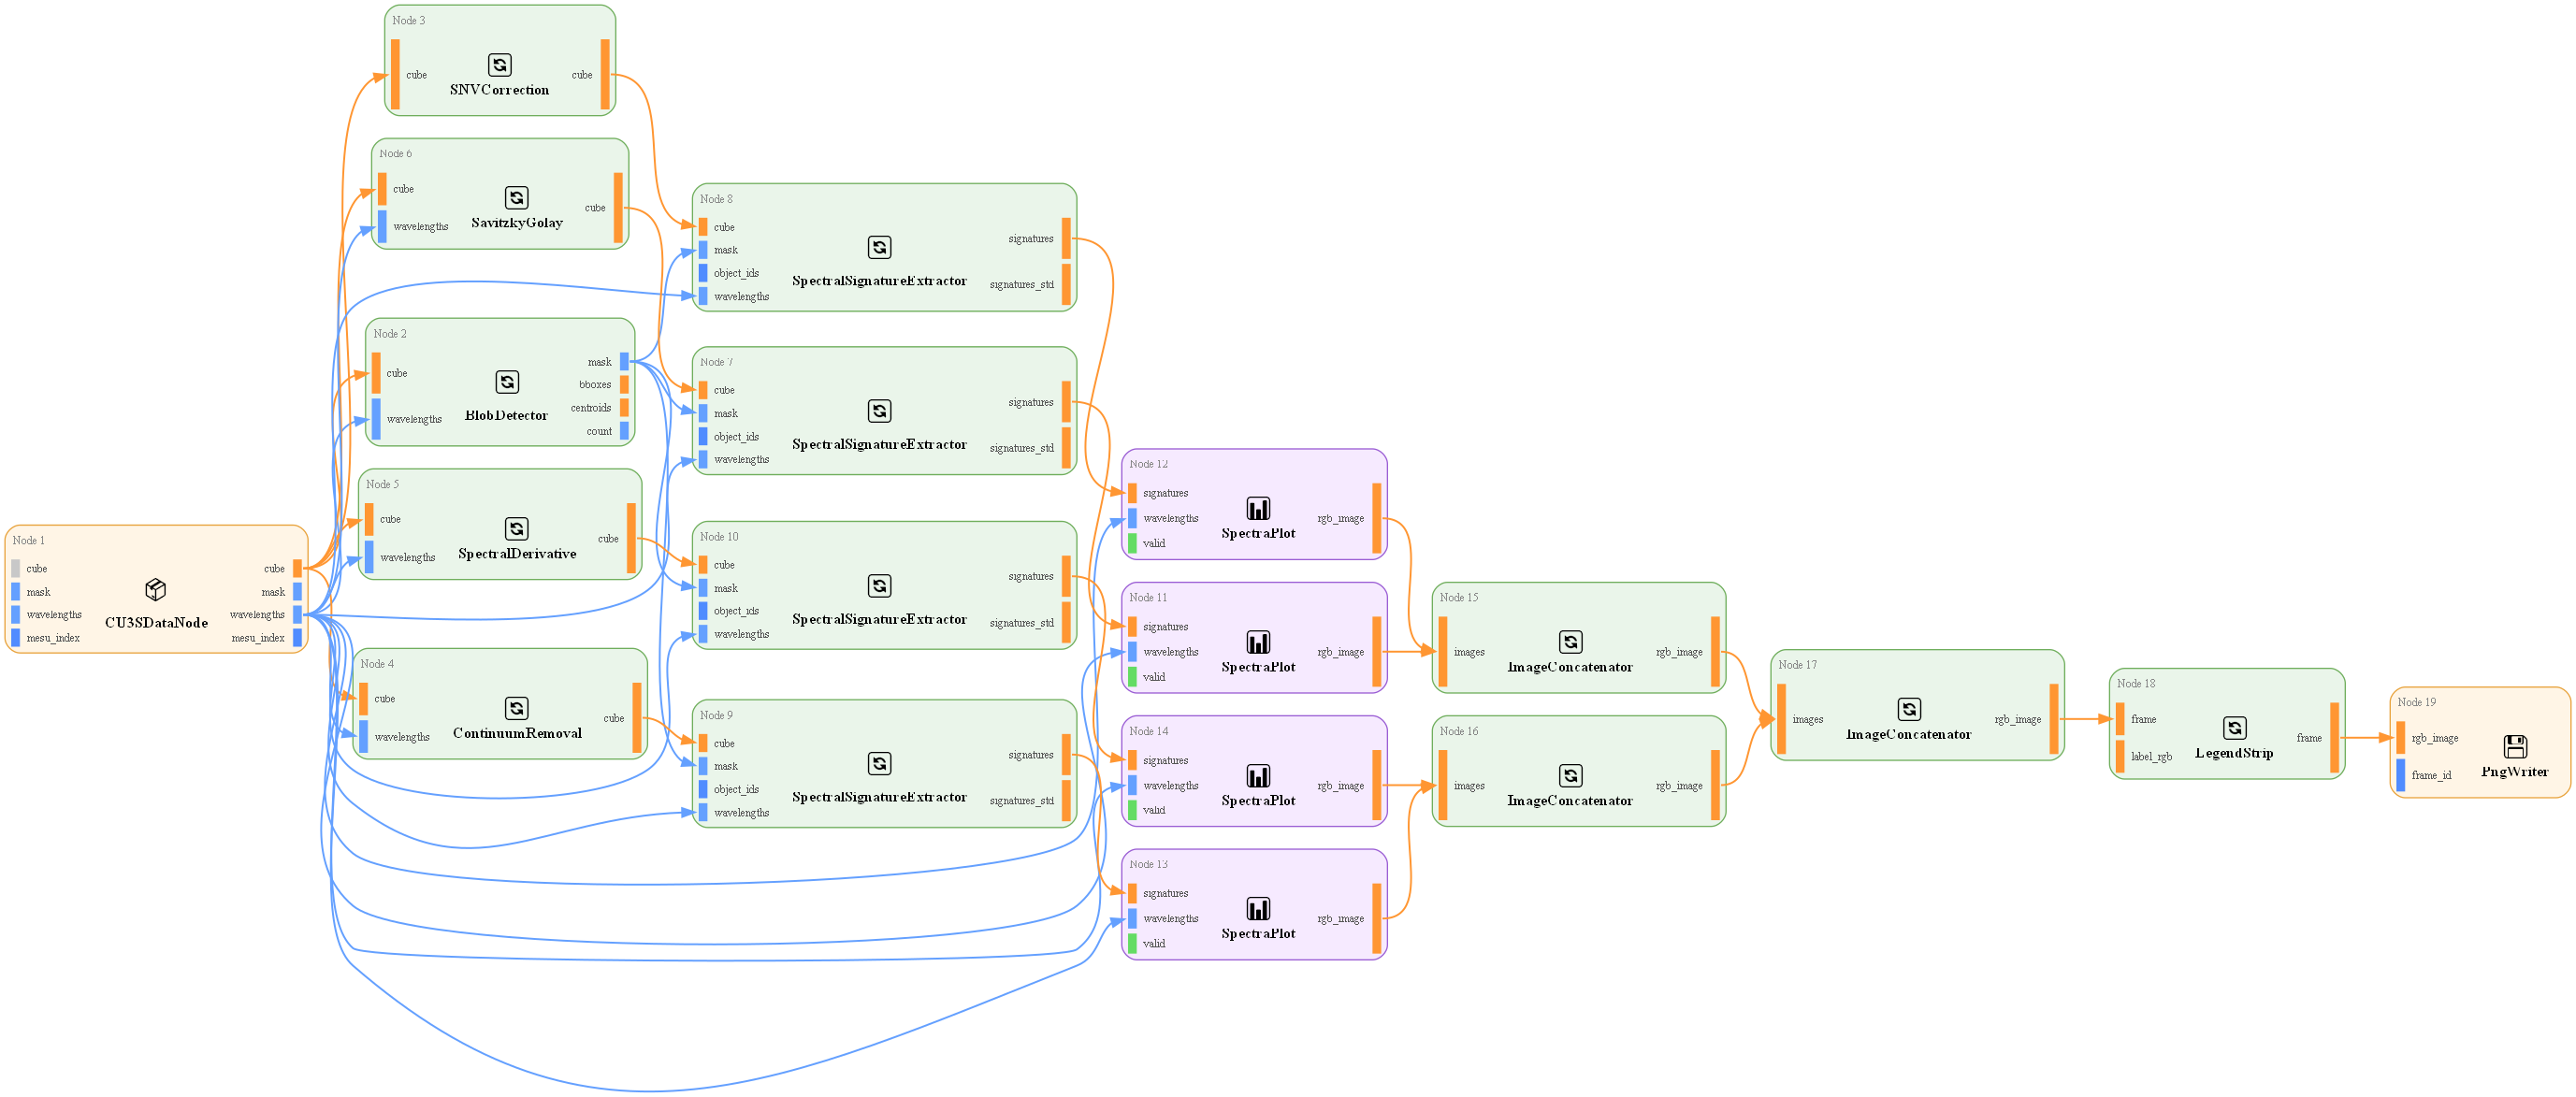

In [8]:
graph_png = pretreatment_pipeline.visualize(
    format="render_graphviz",
    output_path=str(RENDER_DIR / f"{pretreatment_pipeline.name}.png"),
)
display(show_image(graph_png))  # click the image to expand it to full size inline

Predict [pill_pretreatments]:   0%|          | 0/1 [00:00<?, ?batch/s]


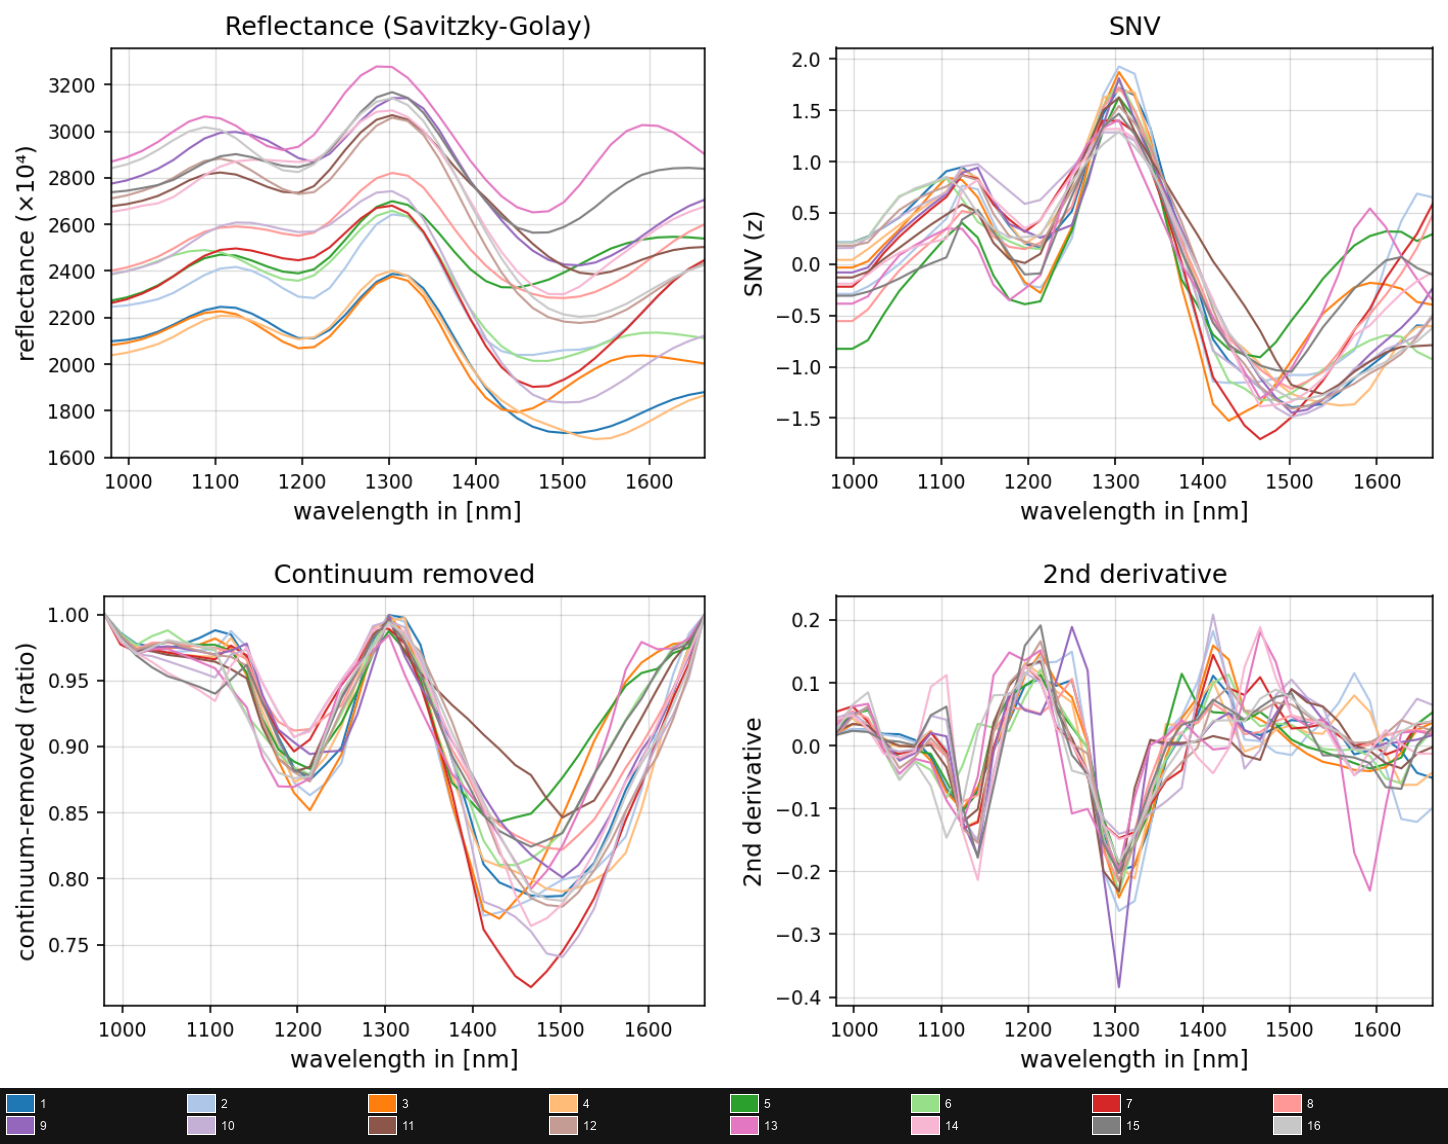

In [9]:
# SpectraPlot panels + ImageConcatenator + LegendStrip composed the 2x2 grid and
# PngWriter wrote it to output/. show_image displays the file (click to expand).
Predictor(pipeline=pretreatment_pipeline, datamodule=dm()).predict(collect_outputs=False)
display(show_image(RENDER_DIR / "pill_pretreatments_strip.png"))

## 4. Unsupervised spectral clustering, rendered with nodes

A cross-check that needs no references: group the pixels by spectrum alone.
`BlobDetector` supplies a foreground mask so `KMeansClusterer` and
`GaussianMixtureClusterer` fit on **pill pixels only** (clustering the whole
frame would otherwise spend most clusters on the tray background). Both are
`requires_initial_fit` nodes fitted with `StatisticalTrainer`.

Each algorithm gets two panels. The **per-pixel** panel colourises the raw
cluster map with the shared palette (`ClassMapToRGB`; the blob mask blacks out
the background) and blends it onto the false-RGB (`LabelOverlay`). The
**per-blob** panel reuses the section-2 voting idea on the clusters:
`MajorityVoteByBlob` takes the majority cluster inside each compartment and
`TrackingOverlayNode` overlays it with the id printed on each blob, exactly the
per-region mask the supervised path produces. `LabelOffset` lifts the 0-based
cluster ids to 1-based first, because the vote treats `0` as background.

With `k=16` the clusters group the products by material: compartments holding
the same tablet share a cluster (their per-blob ids repeat), and a heterogeneous
tablet can split across a few. The cluster ids themselves are arbitrary, so read
*which compartments share a number*, not the number: this is the unsupervised
analogue of section 2's one-label-per-compartment map.

In [10]:
cluster_entries = [(str(i), PALETTE[i]) for i in range(16)]

clu_data = CU3SDataNode(name="data")
clu_blobs = BlobDetector(threshold_method="otsu", min_area=150, keep_largest=16, name="blobs")
clu_cr = ContinuumRemoval(name="continuum")
kmeans = KMeansClusterer(n_clusters=16, random_state=0, name="kmeans")
gmm = GaussianMixtureClusterer(n_components=16, random_state=0, name="gmm")
clu_rgb = FixedWavelengthSelector(
    target_wavelengths=(1450.0, 1250.0, 1050.0), norm_mode="per_frame", name="false_rgb"
)
# per-pixel view: colourise each cluster map with the shared palette (the blob mask
# blacks out the background) and blend it onto the false-RGB.
km_color = ClassMapToRGB(palette=PALETTE, name="km_color")
gmm_color = ClassMapToRGB(palette=PALETTE, name="gmm_color")
km_over = LabelOverlay(alpha=0.65, name="km_over")
gmm_over = LabelOverlay(alpha=0.65, name="gmm_over")
t_km = TitleOverlay(text="KMeans (per-pixel)", font_size=18, name="t_km")
t_gmm = TitleOverlay(text="GMM (per-pixel)", font_size=18, name="t_gmm")
# per-blob view: majority-vote each cluster map inside the blobs to get one cluster
# per compartment, then overlay it with ids. LabelOffset lifts the 0-based cluster
# ids to 1-based first, since MajorityVoteByBlob treats 0 as background.
km_offset = LabelOffset(offset=1, name="km_offset")
gmm_offset = LabelOffset(offset=1, name="gmm_offset")
km_vote = MajorityVoteByBlob(name="km_vote")
gmm_vote = MajorityVoteByBlob(name="gmm_vote")
km_vote_panel = TrackingOverlayNode(draw_ids=True, text_scale=1, name="km_vote_panel")
gmm_vote_panel = TrackingOverlayNode(draw_ids=True, text_scale=1, name="gmm_vote_panel")
t_km_vote = TitleOverlay(text="KMeans per-blob", font_size=18, name="t_km_vote")
t_gmm_vote = TitleOverlay(text="GMM per-blob", font_size=18, name="t_gmm_vote")
clu_strip = ImageConcatenator(gap=8, bg_color=(1.0, 1.0, 1.0), name="strip")
clu_legend = LegendStrip(entries=cluster_entries, n_columns=4, name="legend")
clu_png = PngWriter(output_path=str(RENDER_DIR / "pill_clustering_strip.png"), name="png")

clustering_pipeline = CuvisPipeline("pill_clustering")
clustering_pipeline.connect(
    (clu_data.outputs.cube, clu_blobs.inputs.cube),
    (clu_data.outputs.wavelengths, clu_blobs.inputs.wavelengths),
    (clu_data.outputs.cube, clu_cr.inputs.cube),
    (clu_data.outputs.wavelengths, clu_cr.inputs.wavelengths),
    (clu_cr.outputs.cube, kmeans.inputs.cube),
    (clu_cr.outputs.cube, gmm.inputs.cube),
    # the blob mask restricts the fit to pill pixels (inference still labels all)
    (clu_blobs.outputs.mask, kmeans.inputs.mask),
    (clu_blobs.outputs.mask, gmm.inputs.mask),
    (clu_data.outputs.cube, clu_rgb.inputs.cube),
    (clu_data.outputs.wavelengths, clu_rgb.inputs.wavelengths),
    # per-pixel panels: colourise -> blend -> caption.
    (kmeans.outputs.class_mask, km_color.inputs.class_map),
    (clu_blobs.outputs.mask, km_color.inputs.mask),
    (gmm.outputs.class_mask, gmm_color.inputs.class_map),
    (clu_blobs.outputs.mask, gmm_color.inputs.mask),
    (clu_rgb.outputs.rgb_image, km_over.inputs.rgb_image),
    (km_color.outputs.label_rgb, km_over.inputs.label_rgb),
    (clu_rgb.outputs.rgb_image, gmm_over.inputs.rgb_image),
    (gmm_color.outputs.label_rgb, gmm_over.inputs.label_rgb),
    (km_over.outputs.frame, t_km.inputs.frame),
    (gmm_over.outputs.frame, t_gmm.inputs.frame),
    # per-blob panels: offset 0-based ids to 1-based -> majority vote by blob ->
    # overlay the voted compartment-cluster map with ids.
    (kmeans.outputs.class_mask, km_offset.inputs.class_map),
    (gmm.outputs.class_mask, gmm_offset.inputs.class_map),
    (km_offset.outputs.class_map, km_vote.inputs.identity_mask),
    (clu_blobs.outputs.mask, km_vote.inputs.blob_mask),
    (gmm_offset.outputs.class_map, gmm_vote.inputs.identity_mask),
    (clu_blobs.outputs.mask, gmm_vote.inputs.blob_mask),
    (clu_rgb.outputs.rgb_image, km_vote_panel.inputs.rgb_image),
    (km_vote.outputs.mask, km_vote_panel.inputs.mask),
    (clu_rgb.outputs.rgb_image, gmm_vote_panel.inputs.rgb_image),
    (gmm_vote.outputs.mask, gmm_vote_panel.inputs.mask),
    (km_vote_panel.outputs.rgb_with_overlay, t_km_vote.inputs.frame),
    (gmm_vote_panel.outputs.rgb_with_overlay, t_gmm_vote.inputs.frame),
    # stitch per-pixel + per-blob for each algorithm, then append the legend.
    (t_km.outputs.frame, clu_strip.inputs.images),
    (t_km_vote.outputs.frame, clu_strip.inputs.images),
    (t_gmm.outputs.frame, clu_strip.inputs.images),
    (t_gmm_vote.outputs.frame, clu_strip.inputs.images),
    (clu_strip.outputs.rgb_image, clu_legend.inputs.frame),
    (clu_legend.outputs.frame, clu_png.inputs.rgb_image),
)
clustering_pipeline.to(device)

pill_clustering:
CU3SDataNode()
BlobDetector()
ContinuumRemoval()
KMeansClusterer()
GaussianMixtureClusterer()
FixedWavelengthSelector()
ClassMapToRGB()
ClassMapToRGB()
LabelOverlay()
LabelOverlay()
TitleOverlay()
TitleOverlay()
LabelOffset()
LabelOffset()
MajorityVoteByBlob()
MajorityVoteByBlob()
TrackingOverlayNode()
TrackingOverlayNode()
TitleOverlay()
TitleOverlay()
ImageConcatenator()
LegendStrip()
PngWriter()
Use `pipeline.visualize()` for Graphviz/Mermaid output.


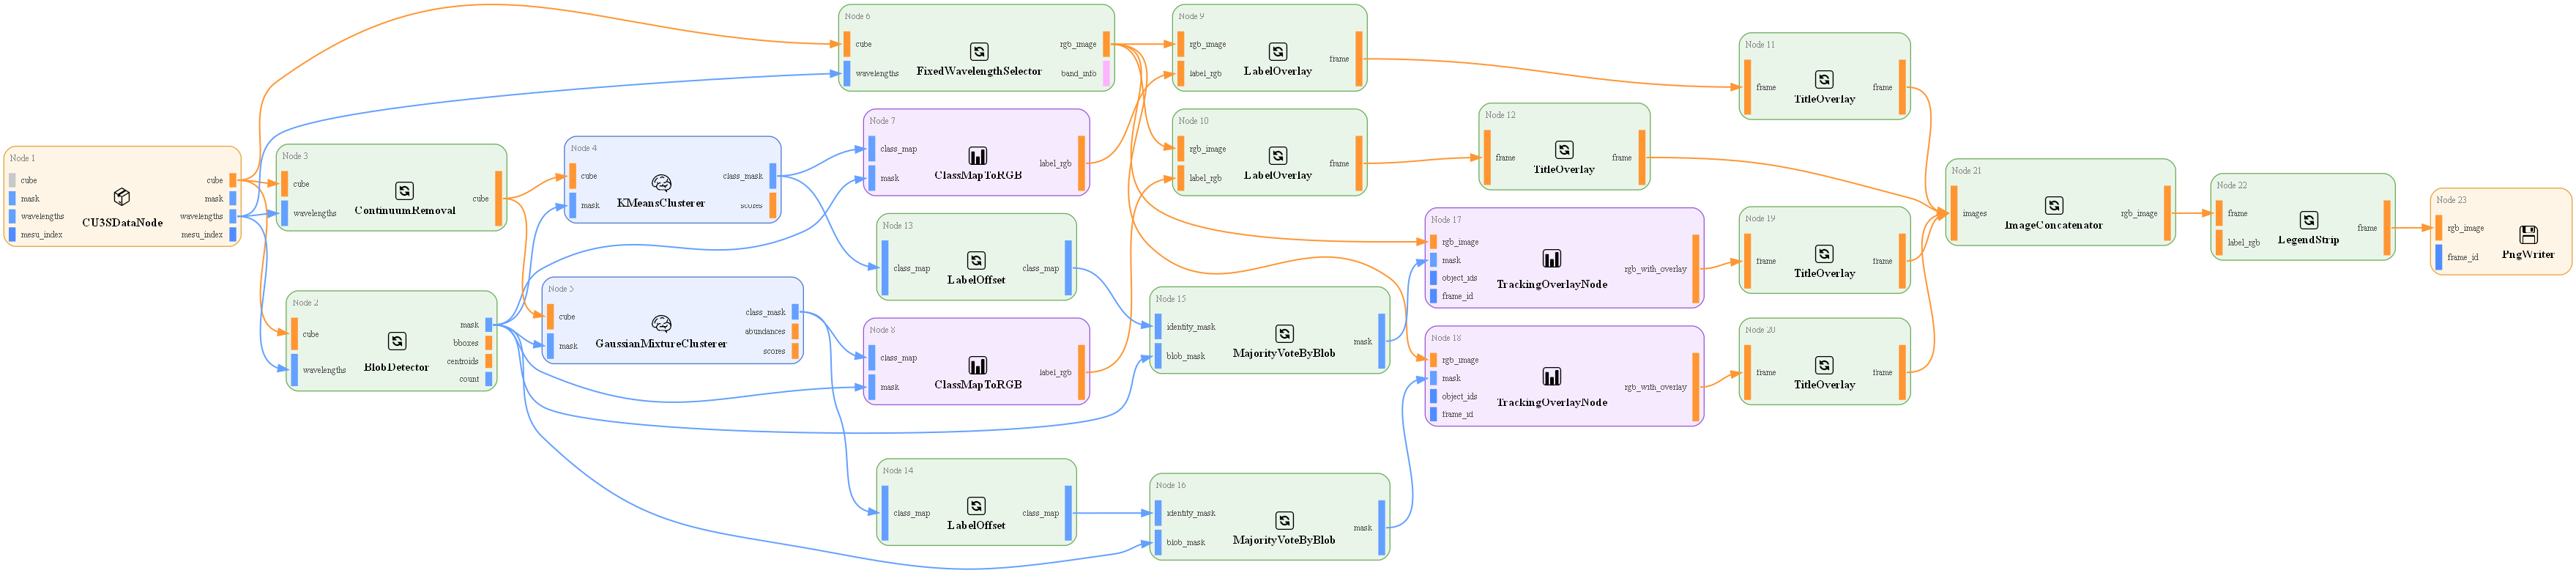

In [11]:
graph_png = clustering_pipeline.visualize(
    format="render_graphviz",
    output_path=str(RENDER_DIR / f"{clustering_pipeline.name}.png"),
)
display(show_image(graph_png))  # click the image to expand it to full size inline

Predict [pill_clustering]:   0%|          | 0/1 [00:00<?, ?batch/s]


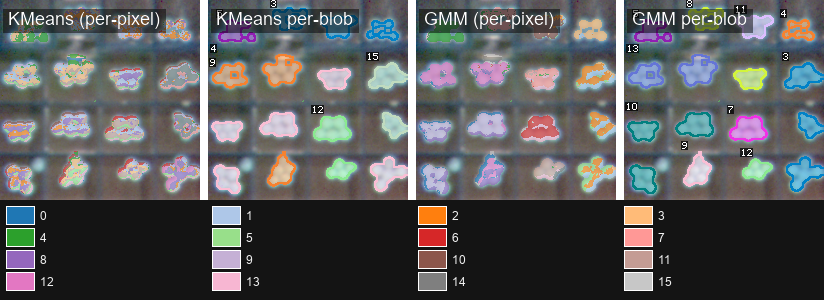

In [12]:
# StatisticalTrainer fits KMeans + GMM on pill pixels; Predictor runs the full graph,
# PngWriter writes the strip to output/, and show_image displays it (click to expand).
StatisticalTrainer(pipeline=clustering_pipeline, datamodule=dm()).fit()
Predictor(pipeline=clustering_pipeline, datamodule=dm()).predict(collect_outputs=False)
display(show_image(RENDER_DIR / "pill_clustering_strip.png"))

## Notes

- Every result above came through the framework: `StatisticalTrainer.fit()` for
  the clustering nodes and `Predictor.predict(collect_outputs=True)` for
  inference, the same path a `restore-trainrun` config drives in production.
- `BlobDetector`, `SignaturesToReferences`, and `MajorityVoteByBlob` are
  pure-torch nodes added to the catalog for this kind of object-level
  inspection; `BlobDetector` reuses the shared OpenCV connected-components helper
  rather than a second hand-rolled labeller.
- `ImageConcatenator` and `PngWriter` keep the final visualization in the graph:
  the section 2-4 strips are composed and written as nodes, so a headless run
  drops each result image without any notebook plotting code.
- **Honest scope:** the clean per-compartment map shows the 16 products are
  separable *within a single scan*, where each compartment is its own reference.
  Transferring those references to a physically re-placed (rotated) tray is a
  much harder problem, illumination and geometry shift each spectrum by more than
  the thin inter-product margin, so cross-scan transfer is not claimed here.
- Swap `ContinuumRemoval` for `SpectralDerivative` to retune the same graph for a
  concentration gradient (same drug at different dosages), where band *depth*,
  not feature *shape*, carries the signal.